With the ideal model selected, this final notebook will create a summary, as well as qq-plots and a scatter plot to visually inspect some of the model assumptions. It will also provide a few final "touch-ups" in the form of robust standard errors and removing a few outliers in the dependent variable. Lastly, the coefficients of the final model and their significance will be displayed in a table.

### The first cells import the necessary packages, mount Google Drive, and upload the data.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.diagnostic as diag
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
Laptop_Data_Reduced = pd.read_csv('Laptop_Data_Reduced.csv')
Laptop_Data_Reduced.head()

,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Company_MSI,Company_Other,Company_Toshiba,OpSys_Linux,OpSys_No OS,OpSys_Windows 7,...,MemoryGB1_Other,MemoryType1_HDD,ScreenResolution_1600x900,ScreenResolution_2560x1440,ScreenResolution_3840x2160,ScreenDisplayType_None,ScreenDisplayType_Quad HD+,ScreenIPSPanel_Yes,ScreenTouchscreen_Yes,Price
0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,30636.000
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,21312.000
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,79653.600
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,41025.600
4,0,0,1,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,20986.992


### This cell splits the data into training and test datasets using "Price" as the dependent variable, and it adds constants to the X_train and X_test data.

In [13]:
X = Laptop_Data_Reduced.drop('Price', axis=1)
y = Laptop_Data_Reduced['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

X_train_constant = sm.add_constant(X_train)
X_test_constant = sm.add_constant(X_test)

### The code will use the following pair of functions.

The first obtains the residuals for the test data. The second creates qqplots for the training and test residuals as well as a scatter plot for the model predictions and training residuals.

In [14]:
def obtain_test_residuals (model, X_test_constant, y_test_trans):
  predictions_test = model.predict(X_test_constant)
  residuals_test = y_test_trans - predictions_test
  return residuals_test

def visuals(model, X_train_constant, residuals_train_weighted, residuals_test_weighted):
  sm.qqplot(residuals_train_weighted, line='r')
  plt.title("Training Residuals Q-Q Plot")
  plt.show()
  ad_test_train = diag.normal_ad(residuals_train_weighted)[1]
  print("Anderson-Darling (Train) p-value: " + str(ad_test_train))

  sm.qqplot(residuals_test_weighted, line='r')
  plt.title("Test Residuals Q-Q Plot")
  plt.show()
  ad_test_test = diag.normal_ad(residuals_test_weighted)[1]
  print("Anderson-Darling (Test) p-value: " + str(ad_test_test))

  plt.scatter(model.predict(X_train_constant), residuals_train_weighted)
  plt.axhline(y=0, color='r', linestyle='-')
  plt.title("Training Residuals Scatter Plot")
  plt.show()
  white_test_train = diag.het_white(residuals_train_weighted, X_train_constant)[1]
  print("White's p-value: " + str(white_test_train))

### This cell displays the model that was chosen in the previous notebook: WLS ln^-2(x).

In [15]:
y_train_trans, y_test_trans = np.power(np.log(y_train), -2), np.power(np.log(y_test), -2)
model_ols = sm.OLS(y_train_trans, X_train_constant).fit()

weights_train = 1 / sm.OLS(abs(model_ols.resid), model_ols.predict(X_train_constant)).fit().fittedvalues**2
test_residuals_ols = obtain_test_residuals(model_ols, X_test_constant, y_test_trans)
weights_test = 1 / sm.OLS(abs(test_residuals_ols), model_ols.predict(X_test_constant)).fit().fittedvalues**2

model_wls = sm.WLS(y_train_trans, X_train_constant, weights = weights_train).fit()
print(model_wls.summary())

                            WLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.844
Model:                            WLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     100.0
Date:                Mon, 28 Jul 2025   Prob (F-statistic):          2.33e-321
Time:                        22:27:32   Log-Likelihood:                 6017.1
No. Observations:                 935   AIC:                        -1.194e+04
Df Residuals:                     886   BIC:                        -1.170e+04
Df Model:                          48                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### This cell acquires the weighted residuals and displays qq-plots to visually inspect their normality, and it also creates a scatter plot to examine heteroscedasticity.

The heteroscedasticity visual is of particular importance because, as mentioned in the last notebook, the White's test statistic is below the critical value of 0.05. This visual can help show if heteroscedasticity is in fact present, or if the test statistic is the result of the large sample size.

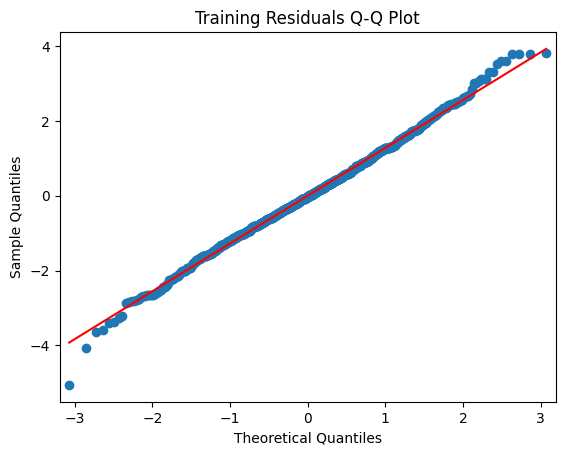

Anderson-Darling (Train) p-value: 0.15883779840968668


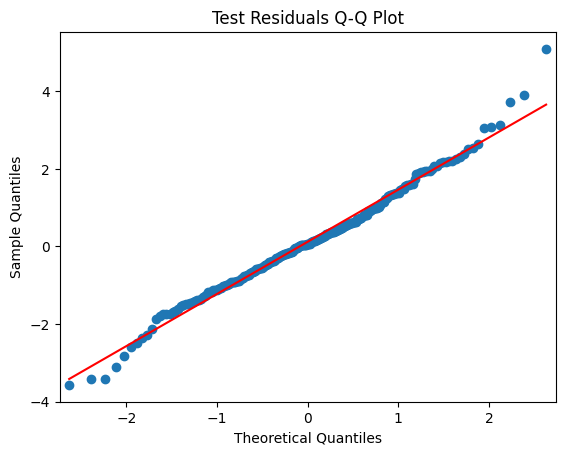

Anderson-Darling (Test) p-value: 0.09598755188908976


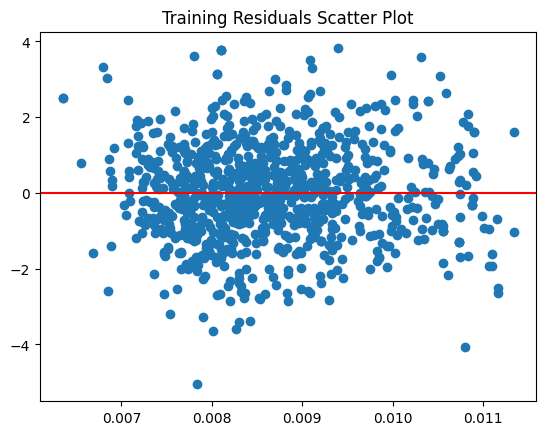

White's p-value: 1.6945689843682747e-07


In [16]:
residuals_train_wls_weighted = model_wls.resid * np.sqrt(weights_train)
test_residuals_wls = obtain_test_residuals(model_wls, X_test_constant, y_test_trans)
residuals_test_wls_weighted = test_residuals_wls * np.sqrt(weights_test)

visuals(model_wls, X_train_constant, residuals_train_wls_weighted, residuals_test_wls_weighted)

There doesn't seem to be a pattern in the scatter plot, which suggests homoscedasticity. All the other metrics seem acceptable as well, though it may be possible to improve the model further by removing some outliers and adding robust standard errors (RSE).

### This cell again splits the data into training and test datasets and adds constants, this time using 250,000 as an upper limit for price.

The box and whisker plot in the first notebook, as well as some trial and error, indicated that this cutoff is most ideal.

In [17]:
Laptop_Data_Reduced = Laptop_Data_Reduced[Laptop_Data_Reduced['Price'] < 250000]

X_reduced = Laptop_Data_Reduced.drop('Price', axis=1)
y_reduced = Laptop_Data_Reduced['Price']

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y_reduced, test_size = 0.2, random_state = 1)

X_train_constant_reduced = sm.add_constant(X_train_reduced)
X_test_constant_reduced = sm.add_constant(X_test_reduced)

### This cell creates a sumary of the model based on the reduced data in the same manner as before, and it also adds robust standard errors to improve the model's inferences.

In [18]:
y_train_trans_reduced, y_test_trans_reduced = np.power(np.log(y_train_reduced), -2), np.power(np.log(y_test_reduced), -2)
model_ols_reduced = sm.OLS(y_train_trans_reduced, X_train_constant_reduced).fit()

weights_train_reduced = 1 / sm.OLS(abs(model_ols_reduced.resid), model_ols_reduced.predict(X_train_constant_reduced)).fit().fittedvalues**2
test_residuals_ols_reduced = obtain_test_residuals(model_ols_reduced, X_test_constant_reduced, y_test_trans_reduced)
weights_test_reduced = 1 / sm.OLS(abs(test_residuals_ols_reduced), model_ols_reduced.predict(X_test_constant_reduced)).fit().fittedvalues**2

model_wls_reduced = sm.WLS(y_train_trans_reduced, X_train_constant_reduced, weights = weights_train_reduced).fit(cov_type='HC3')
print(model_wls_reduced.summary())

                            WLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.848
Model:                            WLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     121.4
Date:                Mon, 28 Jul 2025   Prob (F-statistic):               0.00
Time:                        22:27:39   Log-Likelihood:                 6015.7
No. Observations:                 932   AIC:                        -1.193e+04
Df Residuals:                     883   BIC:                        -1.170e+04
Df Model:                          48                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

The summary shows that various statistics, such as adjusted R-squared and Jarque-bera, have improved even further.

### This cell again obtains weighted residuals and creates qq-plots and a scatter plot, this time on the reduced data.

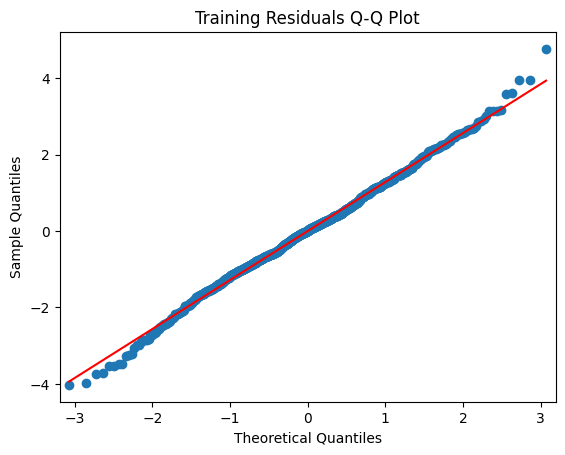

Anderson-Darling (Train) p-value: 0.08500670627896242


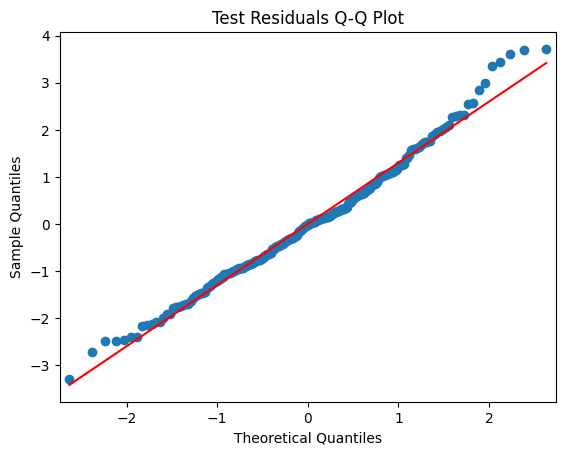

Anderson-Darling (Test) p-value: 0.07918966942726911


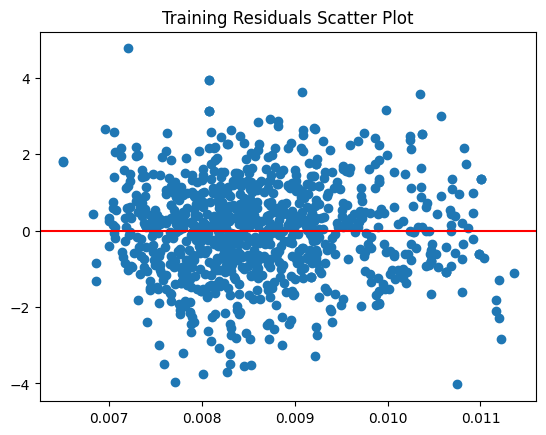

White's p-value: 0.00017672608041284702


In [19]:
residuals_train_wls_weighted_reduced = model_wls_reduced.resid * np.sqrt(weights_train_reduced)
test_residuals_wls_reduced = obtain_test_residuals(model_wls_reduced, X_test_constant_reduced, y_test_trans_reduced)
residuals_test_wls_weighted_reduced = test_residuals_wls_reduced * np.sqrt(weights_test_reduced)

visuals(model_wls_reduced, X_train_constant_reduced, residuals_train_wls_weighted_reduced, residuals_test_wls_weighted_reduced)

The qq-plot p-values remain acceptable. The scatter plot still shows no pattern and its p-value has improved (even if it remains under 0.05).

### This cell displays the predictors, their coefficients, and their statistical significance in one final table.

The significance values are in ascending order, meaning the most significant values (the lowest ones) are near the top.

In [20]:
predictors = model_wls_reduced.model.exog_names
coefficients = model_wls_reduced.params
significance = model_wls_reduced.pvalues

final_model = pd.DataFrame({'Predictor': predictors, 'Coefficient': coefficients.tolist(), 'Significance': significance.tolist()}) \
  .sort_values('Significance')
display(final_model)

,Predictor,Coefficient,Significance
0,const,0.008993,0.000000e+00
21,"CpuType_Low GHz, Low Ram",0.000980,2.035866e-51
19,"CpuType_High GHz, Low Ram",0.000422,1.004184e-21
14,TypeName_Workstation,-0.000749,2.207049e-21
41,MemoryType1_HDD,0.000387,6.063069e-21
18,Inches_17.3,-0.000385,1.702426e-17
7,Company_Toshiba,-0.000535,1.345409e-14
43,ScreenResolution_2560x1440,-0.000676,4.521781e-12
34,Gpu_Nvidia GeForce GTX 1070,-0.000882,1.872347e-11
2,Company_Dell,-0.000368,2.994578e-11


While some predictors are not statistically significant, the goal of the model is understanding, so removing them isn't desireable. It's also crucial to remember that when using the model, the price prediction must be "detransformed" by first raising it to the power of -1/2 and then raising _e_ to the result.